#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [26]:
# For GPU (e.g. local RTX 5060 / Blackwell): install PyTorch with CUDA 12.8 first, then the rest.
# Colab: default pip is fine. Local Windows with NVIDIA GPU (RTX 50 series needs cu128):
#   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#   pip install transformers accelerate bitsandbytes pillow -q
!pip install transformers accelerate bitsandbytes pillow -q
# If you get CPU-only torch, run in terminal (Python 3.12 recommended for cu128):
#   pip uninstall torch torchvision -y
#   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128 --no-cache-dir

import torch

# ----- GPU verification (same as HW2) -----
print("PyTorch version:", torch.__version__)
print(torch.cuda.is_available())       # should be True when GPU is correctly installed
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("CUDA device count:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
True
NVIDIA A100-SXM4-40GB
CUDA device count: 1
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


## Prepare Graph Json and make heatmap to visualize graphs

### Prepare graph json

In [27]:
# 从 Google Drive 下载 HW3 数据并解压到 /data（上一 cell 运行后，下面「Prepare graph json」会自动用 /data 下的 data）
!pip install -q gdown
!mkdir -p /data
# 链接: https://drive.google.com/file/d/1XKpN-CbGlRq2c8pqL-ib3545OvpD_McB/view?usp=sharing
!gdown 1XKpN-CbGlRq2c8pqL-ib3545OvpD_McB --output /content/data.zip
!unzip -q -o /content/data.zip -d /data/

Downloading...
From (original): https://drive.google.com/uc?id=1XKpN-CbGlRq2c8pqL-ib3545OvpD_McB
From (redirected): https://drive.google.com/uc?id=1XKpN-CbGlRq2c8pqL-ib3545OvpD_McB&confirm=t&uuid=7a09361b-5f18-487f-9504-094758349956
To: /content/data.zip
100% 50.7M/50.7M [00:00<00:00, 133MB/s] 


**数据准备（按顺序运行）**  
1. **Part 2.1** 检查数据：解析路径，确认 `DATA_DIR` 下是否有 `graphs_cl`/`LogiOR`/`mps_consistency`。  
2. **Part 2.2** MPS→graph JSON（若需要）。  
3. **Part 2.3** 收集 (graph, text) 对 → `all_pairs`。  
4. **Part 2.4** 校验 JSON 一致性。

In [28]:
# ============================================================
# Part 2.1: 检查数据是否存在（gdown 解压到 /data 或本地 data/）
# ============================================================
import os
import json
from pathlib import Path

def _data_dir_has_content(d):
    return (d / "graphs_cl").exists() or (d / "LogiOR").exists() or (d / "mps_consistency").exists()

# 能组成 train 的 data 目录：除 graphs_cl 外还需至少一个数据集目录 (LogiOR/IndustryOR/...)
def _data_dir_has_datasets(d):
    return any((d / name).exists() for name in ["LogiOR", "IndustryOR", "NLP4LP", "ComplexOR"])

_cwd = Path(os.path.abspath("")).resolve()
HW3_ROOT = None
# 0) 优先：gdown 解压到 /data（整包 HW3 多为 /data/HW3/data 或 /data/data）
_data = Path("/data")
if _data.exists():
    # 需要 data 里既有 graphs_cl 又有至少一个数据集 (LogiOR 等)，才能组成 all_pairs
    for sub in sorted(_data.iterdir()):
        if not sub.is_dir():
            continue
        dd = sub / "data" if (sub / "data").exists() else sub
        if dd == sub and _data_dir_has_content(sub) and _data_dir_has_datasets(sub):
            HW3_ROOT = _data
            break
        if (sub / "data").exists() and _data_dir_has_content(sub / "data") and _data_dir_has_datasets(sub / "data"):
            HW3_ROOT = sub
            break
    if HW3_ROOT is None:
        if (_data / "HW3" / "data").exists() and _data_dir_has_content(_data / "HW3" / "data"):
            HW3_ROOT = _data / "HW3"
        elif (_data / "data").exists() and _data_dir_has_content(_data / "data"):
            HW3_ROOT = _data
        elif _data_dir_has_content(_data):
            HW3_ROOT = Path("/")
if HW3_ROOT is None and os.environ.get("HW3_ROOT"):
    _p = Path(os.environ["HW3_ROOT"]).resolve()
    if (_p / "data").exists():
        HW3_ROOT = _p
# 仅当 cwd 的 data 里既有 graphs_cl 又有数据集目录时才用 cwd（避免误用 Colab 的 /content/data）
if HW3_ROOT is None and (_cwd / "data").exists() and _data_dir_has_content(_cwd / "data") and _data_dir_has_datasets(_cwd / "data"):
    HW3_ROOT = _cwd
if HW3_ROOT is None:
    p = _cwd
    for _ in range(15):
        if not p or p == p.parent:
            break
        if (p / "data").exists() and _data_dir_has_content(p / "data"):
            HW3_ROOT = p
            break
        if (p / "HW3" / "data").exists() and _data_dir_has_content(p / "HW3" / "data"):
            HW3_ROOT = p / "HW3"
            break
        p = p.parent
if HW3_ROOT is None and _cwd.exists():
    for try_name in ["HW3", "MMAI2026/HW3", "workspace/HW3", "project/HW3"]:
        parts = try_name.replace("/", os.sep).split(os.sep)
        cand = _cwd
        for part in parts:
            cand = cand / part
        if cand.exists() and (cand / "data").exists() and _data_dir_has_content(cand / "data"):
            HW3_ROOT = cand
            break
    if HW3_ROOT is None:
        try:
            for sub in _cwd.iterdir():
                if sub.is_dir() and (sub / "data").exists() and _data_dir_has_content(sub / "data"):
                    HW3_ROOT = sub
                    break
            if HW3_ROOT is None:
                for sub in _cwd.iterdir():
                    if sub.is_dir() and (sub / "HW3" / "data").exists() and _data_dir_has_content(sub / "HW3" / "data"):
                        HW3_ROOT = sub / "HW3"
                        break
        except (PermissionError, OSError):
            pass
if HW3_ROOT is None:
    HW3_ROOT = _cwd

DATA_DIR = HW3_ROOT / "data"
GRAPHS_CL_DIR = DATA_DIR / "graphs_cl"
GRAPHS_CL_DIR.mkdir(parents=True, exist_ok=True)
DATASETS = ["LogiOR", "IndustryOR", "NLP4LP", "ComplexOR"]

# ---- 检查并打印 ----
print("HW3_ROOT:", HW3_ROOT)
print("DATA_DIR:", DATA_DIR)
if str(HW3_ROOT).startswith("/data"):
    print("(数据来自 gdown 解压目录 /data)")
print("DATA_DIR.exists():", DATA_DIR.exists())
DATA_OK = DATA_DIR.exists() and _data_dir_has_content(DATA_DIR)
print("数据目录有效 (graphs_cl/LogiOR/mps_consistency 至少有一个):", DATA_OK)
print("DATA_DIR 含数据集目录 (LogiOR 等):", _data_dir_has_datasets(DATA_DIR) if DATA_DIR.exists() else False)
if DATA_DIR.exists():
    subdirs = [x.name for x in DATA_DIR.iterdir() if x.is_dir()]
    print("DATA_DIR 下子目录:", subdirs[:20], "..." if len(subdirs) > 20 else "")
else:
    print("DATA_DIR 不存在")
if not DATA_OK and Path("/data").exists():
    print("/data 下内容 (供排查 gdown 解压结构):")
    for x in sorted(Path("/data").iterdir())[:30]:
        print(" ", x)


HW3_ROOT: /data/HW3_DRIVE
DATA_DIR: /data/HW3_DRIVE/data
(数据来自 gdown 解压目录 /data)
DATA_DIR.exists(): True
数据目录有效 (graphs_cl/LogiOR/mps_consistency 至少有一个): True
DATA_DIR 含数据集目录 (LogiOR 等): True
DATA_DIR 下子目录: ['graphs_cl', 'NLP4LP', 'LogiOR', 'IndustryOR', 'ComplexOR'] 


In [29]:
# ============================================================
# Part 2.2: MPS -> graph JSON（若存在 mps_consistency 则转换，否则用已有 *_graph.json）
# ============================================================
import numpy as np

def _safe_float(v, default=0.0):
    try:
        f = float(v)
        return f if np.isfinite(f) else default
    except (TypeError, ValueError):
        return default

def _mps_to_graph_json(mps_path):
    import gurobipy as gp
    m = gp.read(str(mps_path))
    m.setParam("OutputFlag", 0)
    m.update()
    vars_ = m.getVars()
    cons_ = m.getConstrs()
    A = m.getA()
    var_nodes = [{"id": v.VarName, "type": "var", "vtype": v.VType, "lb": _safe_float(v.LB), "ub": _safe_float(v.UB), "obj": float(v.Obj)} for v in vars_]
    con_nodes = [{"id": c.ConstrName, "type": "constr", "sense": c.Sense, "rhs": float(c.RHS)} for c in cons_]
    edges = []
    Acoo = A.tocoo()
    for r, c, val in zip(Acoo.row, Acoo.col, Acoo.data):
        edges.append({"src": cons_[r].ConstrName, "dst": vars_[c].VarName, "coef": float(val)})
    obj_id = "__OBJ__"
    con_nodes.append({"id": obj_id, "type": "obj", "sense": "min" if m.ModelSense == 1 else "max", "rhs": 0.0})
    for v in vars_:
        if v.Obj != 0.0:
            edges.append({"src": obj_id, "dst": v.VarName, "coef": float(v.Obj)})
    return {"meta": {"num_vars": len(vars_), "num_constrs": len(con_nodes), "num_edges": len(edges)}, "nodes": {"vars": var_nodes, "constrs": con_nodes}, "edges": edges}

total_converted = 0
for ds_name in DATASETS:
    mps_dir = DATA_DIR / "mps_consistency" / ds_name
    out_dir = GRAPHS_CL_DIR / ds_name
    out_dir.mkdir(exist_ok=True)
    if not mps_dir.exists():
        continue
    existing = len(list(out_dir.glob("*_graph.json")))
    mps_files = sorted(mps_dir.glob("*.mps"))
    if existing >= len(mps_files):
        total_converted += existing
        continue
    for mp in mps_files:
        gout = out_dir / f"{mp.stem}_graph.json"
        if gout.exists():
            total_converted += 1
            continue
        try:
            g = _mps_to_graph_json(mp)
            with open(gout, "w", encoding="utf-8") as f:
                json.dump(g, f, allow_nan=False)
            total_converted += 1
        except Exception as e:
            print("  WARN:", mp.name, e)
n_graphs = sum(len(list((GRAPHS_CL_DIR / ds).glob("*_graph.json"))) for ds in DATASETS if (GRAPHS_CL_DIR / ds).exists())
print("Graphs available:", total_converted or n_graphs, "(from MPS conversion or existing JSONs)")


Graphs available: 457 (from MPS conversion or existing JSONs)


In [30]:
# ============================================================
# Part 2.3: 收集 (graph_json, text) 对 -> all_pairs
# ============================================================
all_pairs = []
for ds_name in DATASETS:
    text_dir = DATA_DIR / ds_name
    graph_dir = GRAPHS_CL_DIR / ds_name
    if not text_dir.exists() or not graph_dir.exists():
        continue
    for gpath in sorted(graph_dir.glob("*_graph.json")):
        prob_id = gpath.stem.replace("_graph", "")
        tpath = text_dir / prob_id / "question.txt"
        if not tpath.exists():
            continue
        with open(gpath, "r", encoding="utf-8") as f:
            graph_dict = json.load(f)
        with open(tpath, "r", encoding="utf-8") as f:
            text = f.read().strip()
        if len(text) < 20:
            continue
        all_pairs.append({"graph_dict": graph_dict, "text": text, "prob": f"{ds_name}/{prob_id}", "dataset": ds_name})

print("Total text-graph pairs:", len(all_pairs))
for ds in DATASETS:
    n = sum(1 for p in all_pairs if p["dataset"] == ds)
    if n:
        print(" ", ds + ":", n)


Total text-graph pairs: 457
  LogiOR: 92
  IndustryOR: 83
  NLP4LP: 264
  ComplexOR: 18


In [31]:
# ============================================================
# Part 2.4: 校验 graph JSON 与数据集一致性
# ============================================================
def validate_graph_json(gd):
    errors = []
    meta = gd.get("meta", {})
    nv = len(gd.get("nodes", {}).get("vars", []))
    nc = len(gd.get("nodes", {}).get("constrs", []))
    ne = len(gd.get("edges", []))
    if meta.get("num_vars") != nv:
        errors.append("meta.num_vars != len(vars)")
    if meta.get("num_constrs") != nc:
        errors.append("meta.num_constrs != len(constrs)")
    if meta.get("num_edges") != ne:
        errors.append("meta.num_edges != len(edges)")
    node_ids = set()
    for v in gd.get("nodes", {}).get("vars", []):
        node_ids.add(v.get("id"))
    for c in gd.get("nodes", {}).get("constrs", []):
        node_ids.add(c.get("id"))
    for e in gd.get("edges", []):
        if e.get("src") not in node_ids:
            errors.append("edge src not in nodes")
        if e.get("dst") not in node_ids:
            errors.append("edge dst not in nodes")
    return errors

validation_failed = 0
for p in all_pairs:
    errs = validate_graph_json(p["graph_dict"])
    if errs:
        validation_failed += 1
        if validation_failed <= 3:
            print("  Validation", p["prob"], errs)
if validation_failed:
    print("Validation:", validation_failed, "pairs had issues.")
else:
    print("Validation: all graph JSONs are internally consistent.")


Validation: all graph JSONs are internally consistent.


#### MILP heatmap 可视化说明

**做法（How it’s done）**  
- 从 graph JSON 读出：变量列表、约束列表（去掉 `__OBJ__`）、边（系数）。  
- `_graph_to_milp_arrays` 得到：约束矩阵 **A**、右端 **b**、目标 **c**、约束方向 **sense**、目标方向 **obj_sense**。  
- **增强版（默认）** `render_graph_to_image_enhanced`：  
  - **布局与参考图一致**：**Column (variable) features 放在顶部**（vtype, lb, ub）；**Row (constraint) features 放在左侧**（&lt;, =, &gt;）。  
  - **符号信息放大、不“一个 pixel”**：顶部变量带用 `top_band_block` 像素高（默认 12）画每一行，整块更醒目；左侧约束带用 `left_band_cols` 列（默认 3）重复 sense，整条更宽、易读。  
  - **多像素表示一个值**：主矩阵每格 `block_size × block_size` 像素。  
  - **总结统计**：标题输出 n_var, n_con, density, frac_bin, frac_int。  
- 用 **RdBu_r**（蓝/白/红）统一表示系数、sense、lb/ub、vtype 等，便于对比正负与相对大小。

**图中包含的 MILP 信息（What is included）**  
| 内容 | 位置 |
|------|------|
| 约束矩阵 A | 主矩形，行=约束、列=变量 |
| 右端 b | 每行最右一列 |
| 目标 c、obj_sense | 最后一行 |
| 约束方向 sense | 主区域第 0 列 |
| **变量类型 vtype** | **顶部第 1 行（C/I/B）** |
| **变量边界 lb, ub** | **顶部第 2、3 行（归一化）** |
| **汇总统计** | **标题：n_var, n_con, density, frac_bin, frac_int** |

**仍损失的信息**  
变量/约束名称（id）、行列的精确语义顺序、从颜色反推的绝对数值精度（仍为相对量级）。

**这类图有没有参考意义？**  
有。在运筹、数值线性代数、科学计算里，用矩阵热图/稀疏模式图做 **结构可视化** 是常见做法：看稀疏性、块结构、对角线等，用于问题分类、选求解器、调试建模。增强版在保留结构的同时加入了 vtype/lb/ub 和汇总统计，更贴近完整 MILP 的“指纹”。

### graph visualization

In [32]:
def _safe_float(v, default=0.0):
    try:
        f = float(v)
        return f if np.isfinite(f) else default
    except (TypeError, ValueError):
        return default

def _graph_to_milp_arrays(gd):
    """Build matrix A, objective c, RHS b, and sense from graph JSON. Exclude __OBJ__ from constraint rows."""
    vars_list = gd.get("nodes", {}).get("vars", [])
    cons_list = gd.get("nodes", {}).get("constrs", [])
    edges = gd.get("edges", [])
    var_id2j = {v["id"]: j for j, v in enumerate(vars_list)}
    con_ids = [c["id"] for c in cons_list if c.get("id") != "__OBJ__" and c.get("type") != "obj"]
    con_id2i = {cid: i for i, cid in enumerate(con_ids)}
    n_con, n_var = len(con_ids), len(vars_list)
    A = np.zeros((n_con, n_var))
    b = np.zeros(n_con)
    c = np.zeros(n_var)
    sense_map = {"<": -1.0, "=": 0.0, ">": 1.0}
    sense = np.zeros(n_con)
    obj_sense = 0.0
    for i, cid in enumerate(con_ids):
        con_node = next((x for x in cons_list if x["id"] == cid), None)
        if con_node:
            b[i] = con_node.get("rhs", 0.0)
            sense[i] = sense_map.get(con_node.get("sense", "="), 0.0)
    for cnd in cons_list:
        if cnd.get("id") == "__OBJ__" or cnd.get("type") == "obj":
            obj_sense = 1.0 if cnd.get("sense") == "max" else -1.0
            break
    for e in edges:
        src, dst, coef = e.get("src"), e.get("dst"), float(e.get("coef", 0))
        if src == "__OBJ__" or (next((x for x in cons_list if x["id"] == src), {}).get("type") == "obj"):
            if dst in var_id2j:
                c[var_id2j[dst]] = coef
        elif src in con_id2i and dst in var_id2j:
            A[con_id2i[src], var_id2j[dst]] = coef
    return A, b, c, sense, obj_sense, n_con, n_var

def _graph_to_var_attributes(gd):
    """Variable-level: vtype (C=0, I=0.5, B=1), lb, ub. For use in symbolic band."""
    vars_list = gd.get("nodes", {}).get("vars", [])
    n_var = len(vars_list)
    vtype_map = {"C": 0.0, "I": 0.5, "B": 1.0}
    vtype = np.array([vtype_map.get(v.get("vtype", "C"), 0.0) for v in vars_list])
    lb = np.array([_safe_float(v.get("lb"), 0.0) for v in vars_list])
    ub = np.array([min(_safe_float(v.get("ub"), 1e6), 1e6) for v in vars_list])
    return vtype, lb, ub, n_var

def _compute_graph_stats_simple(gd):
    """Summary stats for annotation: n_var, n_con, density, frac_bin, frac_int."""
    vars_list = gd.get("nodes", {}).get("vars", [])
    cons_list = gd.get("nodes", {}).get("constrs", [])
    edges = gd.get("edges", [])
    n_var = len(vars_list)
    n_con = len([c for c in cons_list if c.get("id") != "__OBJ__" and c.get("type") != "obj"])
    n_edges = len(edges)
    density = n_edges / max(n_var * n_con, 1)
    vtypes = [v.get("vtype", "C") for v in vars_list]
    frac_bin = sum(1 for t in vtypes if t == "B") / max(n_var, 1)
    frac_int = sum(1 for t in vtypes if t == "I") / max(n_var, 1)
    return n_var, n_con, density, frac_bin, frac_int

def render_graph_to_image_enhanced(gd, out_path, figsize=(12, 10), dpi=100, block_size=6,
                                   top_band_block=12, left_band_cols=3):
    """
    Layout like reference: Column (variable) features padded at TOP (vtype, lb, ub), row (constraint) features
    padded at LEFT (</=/>). Symbolic bands are MAGNIFIED: top band uses top_band_block px per row, left band
    uses left_band_cols columns so sense is wide and visible.
    """
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        from PIL import Image, ImageDraw
        img = Image.new("RGB", (640, 480), color=(255, 255, 255))
        d = ImageDraw.Draw(img)
        nv = len(gd.get("nodes", {}).get("vars", []))
        nc = len(gd.get("nodes", {}).get("constrs", []))
        d.text((20, 20), f"MILP: {nv} vars, {nc} constraints (install matplotlib)", fill=(0, 0, 0))
        img.save(out_path)
        return
    A, b, c, sense, obj_sense, n_con, n_var = _graph_to_milp_arrays(gd)
    if n_con == 0 or n_var == 0:
        from PIL import Image, ImageDraw
        img = Image.new("RGB", (640, 480), color=(255, 255, 255))
        d = ImageDraw.Draw(img)
        d.text((20, 20), f"MILP: {n_var} vars, {n_con} constraints (empty A)", fill=(0, 0, 0))
        img.save(out_path)
        return
    vtype, lb, ub, _ = _graph_to_var_attributes(gd)
    n_var2, n_con2, density, frac_bin, frac_int = _compute_graph_stats_simple(gd)
    cap = max(float(np.nanmax(np.abs(np.r_[lb, ub]))), 1e-6)
    lb_norm = np.clip(lb / cap, -1.0, 1.0)
    ub_norm = np.clip(ub / cap, -1.0, 1.0)
    vtype_show = np.clip(vtype * 2.0 - 0.5, -1.0, 1.0)
    # ---- 1) TOP BAND: variable features (vtype, lb, ub) - PADDED AT TOP, magnified height ----
    # Shape (3, left_band_cols + n_var + 1). Cols 0..left_band_cols-1 = neutral; cols [L..L+n_var-1] = vtype/lb/ub; last col = neutral
    L = left_band_cols
    top_grid = np.zeros((3, L + n_var + 1))
    top_grid[:, :L] = np.nan
    top_grid[:, L : L + n_var] = np.vstack([vtype_show, lb_norm, ub_norm])
    top_grid[:, L + n_var :] = np.nan
    # Expand top band: each logical row -> top_band_block pixels tall, each col -> block_size wide (so aligns with main)
    top_big = np.kron(top_grid, np.ones((top_band_block, block_size)))
    top_mask = np.kron(np.isnan(top_grid), np.ones((top_band_block, block_size), dtype=bool))
    top_big = np.where(top_mask, 0.0, top_big)
    # ---- 2) MAIN BODY: left band (sense </=/>) + A + b; last row = 0, c, obj_sense ----
    # Shape (n_con+1, L + n_var + 1). Cols 0..L-1 = sense repeated (magnified width); col L..L+n_var-1 = A; col L+n_var = b
    main_grid = np.zeros((n_con + 1, L + n_var + 1))
    for j in range(L):
        main_grid[:n_con, j] = sense
    main_grid[:n_con, L : L + n_var] = A
    main_grid[:n_con, L + n_var] = b
    main_grid[n_con, :L] = 0.0
    main_grid[n_con, L : L + n_var] = c
    main_grid[n_con, L + n_var] = obj_sense
    main_big = np.kron(main_grid, np.ones((block_size, block_size)))
    # ---- 3) Stack: [top band | main body] vertically ----
    full = np.vstack([top_big, main_big])
    v_abs = max(float(np.nanmax(np.abs(full))), 1.0)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.imshow(full, cmap="RdBu_r", aspect="auto", vmin=-v_abs, vmax=v_abs, interpolation="nearest")
    ax.set_ylabel("TOP BAND: vtype / lb / ub (per var) | BODY: constraints | last row: objective")
    ax.set_xlabel("LEFT BAND: sense </=/> (repeated %d cols) | A (vars) | RHS" % L)
    plt.colorbar(im, ax=ax, label="blue=neg, red=pos; vtype C/I/B; sense </=/>")
    title = "MILP: top=var features (magnified), left=row sense (magnified) | n_var=%d n_con=%d density=%.3f frac_bin=%.2f frac_int=%.2f"
    ax.set_title(title % (n_var2, n_con2, density, frac_bin, frac_int))
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

def render_graph_to_image(gd, out_path, figsize=(10, 8), dpi=100, enhanced=True, block_size=6,
                         top_band_block=12, left_band_cols=3):
    """Render MILP as 2D heatmap. If enhanced=True: top band = var features (magnified), left band = sense (magnified)."""
    if enhanced:
        render_graph_to_image_enhanced(gd, out_path, figsize=figsize, dpi=dpi, block_size=block_size,
                                       top_band_block=top_band_block, left_band_cols=left_band_cols)
        return
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        from PIL import Image, ImageDraw
        img = Image.new("RGB", (640, 480), color=(255, 255, 255))
        d = ImageDraw.Draw(img)
        nv = len(gd.get("nodes", {}).get("vars", []))
        nc = len(gd.get("nodes", {}).get("constrs", []))
        d.text((20, 20), f"MILP: {nv} vars, {nc} constraints (install matplotlib for heatmap)", fill=(0, 0, 0))
        img.save(out_path)
        return
    A, b, c, sense, obj_sense, n_con, n_var = _graph_to_milp_arrays(gd)
    if n_con == 0 or n_var == 0:
        from PIL import Image, ImageDraw
        img = Image.new("RGB", (640, 480), color=(255, 255, 255))
        d = ImageDraw.Draw(img)
        d.text((20, 20), f"MILP: {n_var} vars, {n_con} constraints (empty A)", fill=(0, 0, 0))
        img.save(out_path)
        return
    grid = np.zeros((n_con + 1, n_var + 2))
    grid[:n_con, 0] = sense
    grid[:n_con, 1 : n_var + 1] = A
    grid[:n_con, n_var + 1] = b
    grid[n_con, 0] = 0.0
    grid[n_con, 1 : n_var + 1] = c
    grid[n_con, n_var + 1] = obj_sense
    v_abs = max(float(np.nanmax(np.abs(grid))), 1.0)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.imshow(grid, cmap="RdBu_r", aspect="auto", vmin=-v_abs, vmax=v_abs)
    ax.set_ylabel("rows: constraints (top); last row: objective")
    ax.set_xlabel("col0: sense; cols1..n: A; last col: RHS / obj_sense")
    plt.colorbar(im, ax=ax, label="coefficient (blue=neg, red=pos); sense </=/>")
    plt.title("MILP heatmap: constraint matrix A, RHS b, objective c")
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)


### prepare train val test datasets

In [33]:
# ----- 检查：路径与数量（不渲染，仅打印，便于排查断连/路径问题） -----
from pathlib import Path

print("=== 路径与数量检查 ===")
print("HW3_ROOT:", HW3_ROOT)
print("DATA_DIR:", DATA_DIR)
mmai_dir = Path(HW3_ROOT) / "mmai-data"
img_dir = mmai_dir / "images"
print("MMAI_DIR (将写入):", mmai_dir)
print("IMG_DIR (将写入):", img_dir)
print()
print("all_pairs 数量:", len(all_pairs))
import random as _r
_rng = _r.Random(42)
_sh = all_pairs[:]
_rng.shuffle(_sh)
_nt = int(round(0.80 * len(_sh)))
print("将生成 train 图像数:", _nt)
print("将生成 test 图像数:", len(_sh) - _nt)
print("将生成图像总数:", len(_sh))
print()
if all_pairs:
    import re as _re
    p0 = _sh[0]
    safe0 = _re.sub(r"[^\w\-]", "_", p0["prob"])
    ex_rel = f"images/train_{safe0}_0.png"
    ex_abs = img_dir / f"train_{safe0}_0.png"
    print("示例 (第 1 条): 相对", ex_rel)
    print("        绝对", ex_abs)
print()
if img_dir.exists():
    existing = list(img_dir.glob("*.png"))
    print("IMG_DIR 下已有 .png 数量:", len(existing))
else:
    print("IMG_DIR 尚未创建")
print()
print("断连多为 CPU 内存不足(非 GPU)。下方 Build 可设 MAX_IMAGES=100 先试跑少量。")


=== 路径与数量检查 ===
HW3_ROOT: /data/HW3_DRIVE
DATA_DIR: /data/HW3_DRIVE/data
MMAI_DIR (将写入): /data/HW3_DRIVE/mmai-data
IMG_DIR (将写入): /data/HW3_DRIVE/mmai-data/images

all_pairs 数量: 457
将生成 train 图像数: 366
将生成 test 图像数: 91
将生成图像总数: 457

示例 (第 1 条): 相对 images/train_IndustryOR_prob_064_0.png
        绝对 /data/HW3_DRIVE/mmai-data/images/train_IndustryOR_prob_064_0.png

IMG_DIR 下已有 .png 数量: 458

断连多为 CPU 内存不足(非 GPU)。下方 Build 可设 MAX_IMAGES=100 先试跑少量。


In [34]:
# ----- Build mmai-data for VLM: images + data.jsonl -----
import random
import re
import json
import gc

# Colab 上可设 False：不生成图像，直接使用已有图像（路径与本地一致 HW3/mmai-data/images）
GENERATE_IMAGE = False
# 限制渲染数量可防 Colab 断连。仅当 GENERATE_IMAGE=True 时有效；None=不限制
MAX_IMAGES = None

MMAI_DIR = HW3_ROOT / "mmai-data"
IMG_DIR = MMAI_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

SEED, TRAIN_FRAC, TEST_FRAC = 42, 0.80, 0.20
rng = random.Random(SEED)
shuffled = all_pairs[:]
rng.shuffle(shuffled)
n = len(shuffled)
n_train = int(round(TRAIN_FRAC * n))
train_pairs = shuffled[:n_train]
test_pairs = shuffled[n_train:]
if MAX_IMAGES is not None:
    n_tr = min(len(train_pairs), max(1, int(MAX_IMAGES * TRAIN_FRAC)))
    n_te = min(len(test_pairs), max(1, MAX_IMAGES - n_tr))
    train_pairs = train_pairs[:n_tr]
    test_pairs = test_pairs[:n_te]
    print(f"MAX_IMAGES={MAX_IMAGES} -> train={len(train_pairs)}, test={len(test_pairs)}")
print(f"\nSplit: train={len(train_pairs)}, test={len(test_pairs)}")

STRUCTURE_QUESTION = (
    "Describe the structure of this MILP heatmap: "
    "number of variables, number of constraints, matrix density, "
    "fraction of binary variables, fraction of integer variables, "
    "and objective direction (minimize or maximize)."
)

def _extract_ground_truth(gd):
    """Extract structured ground truth from graph_dict that is visible in the heatmap."""
    vars_list = gd.get("nodes", {}).get("vars", [])
    cons_list = gd.get("nodes", {}).get("constrs", [])
    edges = gd.get("edges", [])

    n_var = len(vars_list)
    n_con = len([c for c in cons_list if c.get("id") != "__OBJ__" and c.get("type") != "obj"])
    n_edges = len(edges)
    density = n_edges / max(n_var * n_con, 1)

    # Bucket density into 3 levels to make the task easier
    if density < 0.2:
        density_cat = "low"
    elif density <= 0.5:
        density_cat = "medium"
    else:
        density_cat = "high"

    vtypes = [v.get("vtype", "C") for v in vars_list]
    frac_bin = sum(1 for t in vtypes if t == "B") / max(n_var, 1)
    frac_int = sum(1 for t in vtypes if t == "I") / max(n_var, 1)

    obj_sense = "minimize"
    for c in cons_list:
        if c.get("id") == "__OBJ__" or c.get("type") == "obj":
            obj_sense = "maximize" if c.get("sense") == "max" else "minimize"
            break

    return (
        f"Variables: {n_var}, Constraints: {n_con}, "
        f"Density: {density_cat}, "
        f"Binary: {frac_bin:.0%}, Integer: {frac_int:.0%}, "
        f"Objective: {obj_sense}"
    )

def build_mmai_records(pairs, split_name, generate_image=True):
    records = []
    total = len(pairs)
    for i, p in enumerate(pairs):
        safe_id = re.sub(r"[^\w\-]", "_", p["prob"])
        img_name = f"{split_name}_{safe_id}_{i}.png"
        img_path = IMG_DIR / img_name
        rel_path = f"images/{img_name}"
        if generate_image:
            try:
                render_graph_to_image(p["graph_dict"], img_path)
            finally:
                try:
                    import matplotlib.pyplot as plt
                    plt.close("all")
                except Exception:
                    pass
            if (i + 1) % 50 == 0 or (i + 1) == total:
                print(f"  {split_name}: {i + 1}/{total}", flush=True)
            if (i + 1) % 100 == 0:
                gc.collect()
        records.append({
            "image": rel_path,
            "question": STRUCTURE_QUESTION,
            "answer": _extract_ground_truth(p["graph_dict"]),
        })
    return records

if GENERATE_IMAGE:
    print("Rendering train images...")
else:
    print("generate_image=False: 使用已有图像，仅生成 jsonl（图像路径 HW3/mmai-data/images）")
train_records = build_mmai_records(train_pairs, "train", generate_image=GENERATE_IMAGE)
test_records = build_mmai_records(test_pairs, "test", generate_image=GENERATE_IMAGE)

# Write data.jsonl (train only for training; we also write test for evaluation)
train_jsonl = MMAI_DIR / "data_train.jsonl"
test_jsonl = MMAI_DIR / "data_test.jsonl"
with open(train_jsonl, "w", encoding="utf-8") as f:
    for r in train_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
with open(test_jsonl, "w", encoding="utf-8") as f:
    for r in test_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

# Single data.jsonl pointing to train (for compatibility with notebook training cell)
data_jsonl = MMAI_DIR / "data.jsonl"
with open(data_jsonl, "w", encoding="utf-8") as f:
    for r in train_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"Saved: {train_jsonl} ({len(train_records)}), {test_jsonl} ({len(test_records)}), {data_jsonl}")
print(f"Images dir: {IMG_DIR}")
n_imgs = len(list(IMG_DIR.glob("*.png"))) if IMG_DIR.exists() else 0
print(f"Image count: {n_imgs} (jsonl 中 image 路径为相对路径，如 images/train_xxx.png，加载时以 MMAI_DIR 为 base)")
DATA_JSONL = str(data_jsonl)
print(f"DATA_JSONL = \"{DATA_JSONL}\"")


Split: train=366, test=91
generate_image=False: 使用已有图像，仅生成 jsonl（图像路径 HW3/mmai-data/images）
Saved: /data/HW3_DRIVE/mmai-data/data_train.jsonl (366), /data/HW3_DRIVE/mmai-data/data_test.jsonl (91), /data/HW3_DRIVE/mmai-data/data.jsonl
Images dir: /data/HW3_DRIVE/mmai-data/images
Image count: 458 (jsonl 中 image 路径为相对路径，如 images/train_xxx.png，加载时以 MMAI_DIR 为 base)
DATA_JSONL = "/data/HW3_DRIVE/mmai-data/data.jsonl"


### 数据抽查：随机各取一条 JSON / MPS / 图像 打印或显示

=== 随机一条 Graph JSON (all_pairs) ===
prob: NLP4LP/prob_156
meta: {'num_vars': 2, 'num_constrs': 4, 'num_edges': 7}
text 前 200 字: A mine sends ore to the surface in small and large wagons. A small wagon hold 20 units of ore while a large wagon holds 50 units of ore. To avoid taking up too much space on the ramps, the number of s...

=== MPS: 未找到 mps_consistency 下 .mps 文件，跳过 ===

=== 随机一张图像 ===
path: /data/HW3_DRIVE/mmai-data/images/test_LogiOR_prob_048_72.png


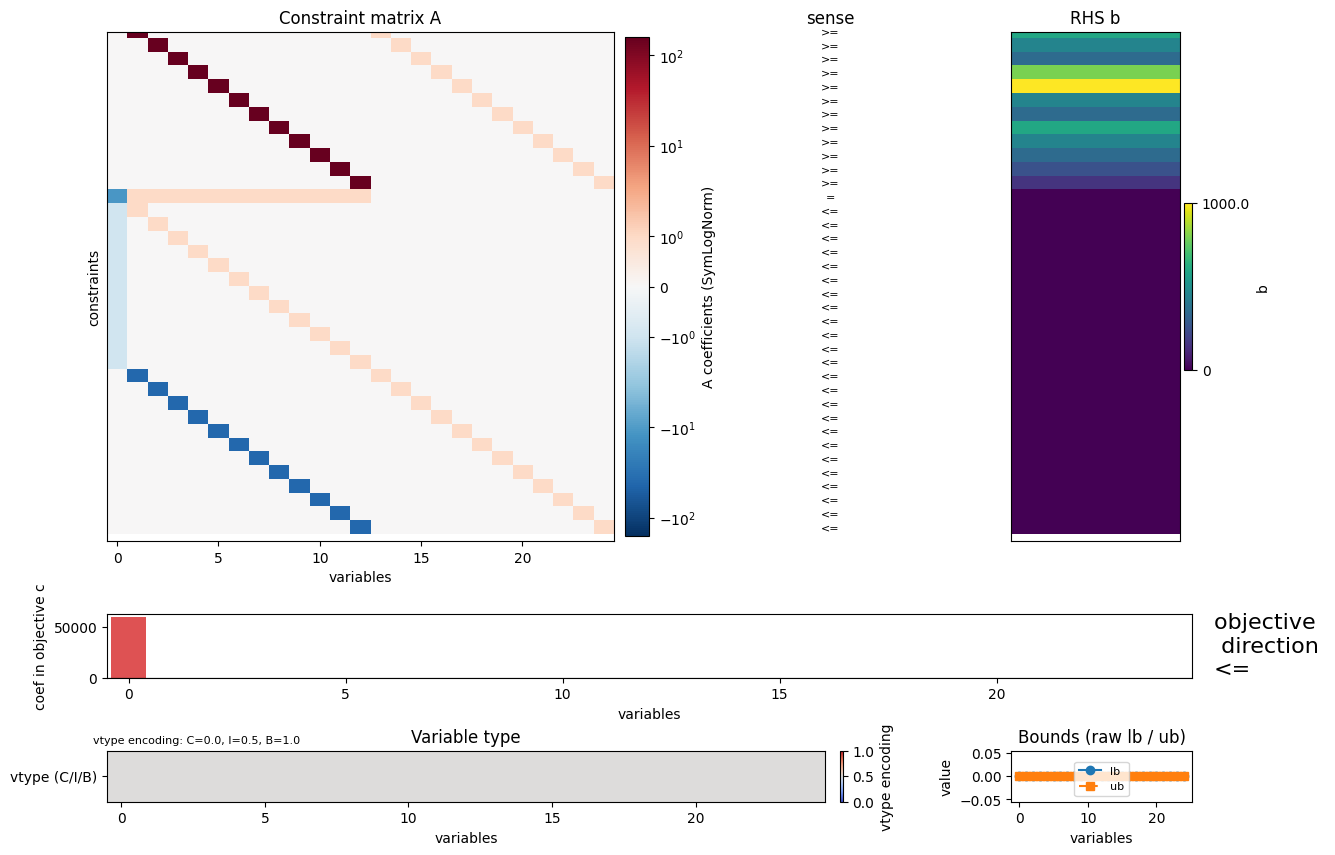

In [35]:
import random as _r
from pathlib import Path

# ----- 1) Graph JSON：从 all_pairs 随机取一条，打印 meta 与 text 片段 -----
if all_pairs:
    p = _r.choice(all_pairs)
    g = p["graph_dict"]
    print("=== 随机一条 Graph JSON (all_pairs) ===")
    print("prob:", p["prob"])
    print("meta:", g.get("meta", {}))
    print("text 前 200 字:", (p["text"][:200] + "...") if len(p["text"]) > 200 else p["text"])
    print()

# ----- 2) MPS：从 mps_consistency 下随机取一个 .mps 文件，打印路径与前几行 -----
mps_files = []
for ds in ["LogiOR", "IndustryOR", "NLP4LP", "ComplexOR"]:
    d = Path(DATA_DIR) / "mps_consistency" / ds
    if d.exists():
        mps_files.extend(list(d.glob("*.mps")))
if mps_files:
    mps_path = _r.choice(mps_files)
    print("=== 随机一个 MPS 文件 ===")
    print("path:", mps_path)
    with open(mps_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()[:15]
    print("前 15 行:")
    for line in lines:
        print(" ", line.rstrip())
    print()
else:
    print("=== MPS: 未找到 mps_consistency 下 .mps 文件，跳过 ===")
    print()

# ----- 3) Image：从 mmai-data/images 随机取一张并显示 -----
img_dir = Path(MMAI_DIR) / "images"
pngs = list(img_dir.glob("*.png")) if img_dir.exists() else []
if pngs:
    img_path = _r.choice(pngs)
    print("=== 随机一张图像 ===")
    print("path:", img_path)
    try:
        from PIL import Image
        img = Image.open(img_path).convert("RGB")
        try:
            from IPython.display import display as ipy_display
            ipy_display(img)
        except Exception:
            display(img)
    except Exception as e:
        print("显示失败:", e)
else:
    print("=== Image: mmai-data/images 下暂无 .png，请先运行上方 Build 并设 GENERATE_IMAGE=True 或放入已有图像 ===")


## for colab

In [36]:
# import os, shutil, zipfile
# from pathlib import Path

# # ============================================================
# # ######################## CHANGE ME #########################
# # ============================================================
# # Upload your dataset as a zip file to Google Drive, then
# # replace the URL below with your own Google Drive share link.
# #
# # Your zip should unpack into a folder called mmai-data/ with:
# #   mmai-data/
# #   ├── images/
# #   │   ├── image_01.jpg
# #   │   ├── ...
# #   │   └── image_16.jpg
# #   └── data.jsonl
# #
# # Each line in data.jsonl should be a JSON object with three
# # fields: "image", "question", and "answer". For example:
# #
# #   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
# #   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
# #
# URL = "https://drive.google.com/file/d/14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw/view?usp=sharing"
# # ============================================================
# # ###################### END CHANGE ME #######################
# # ============================================================

# DATA_DIR = Path("/content/")
# DATA_DIR.mkdir(parents=True, exist_ok=True)

# !pip -q install gdown
# import gdown

# print("Downloading…")
# downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
# if not downloaded_path or not os.path.exists(downloaded_path):
#     raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

# src = Path(downloaded_path)
# dst = DATA_DIR / src.name
# if src.resolve() != dst.resolve():
#     shutil.move(str(src), str(dst))

# print(f"\nFile saved to: {dst}")

# if zipfile.is_zipfile(dst):
#     extract_dir = DATA_DIR / dst.stem
#     extract_dir.mkdir(exist_ok=True)
#     print(f"Unzipping into: {extract_dir}")
#     with zipfile.ZipFile(dst, "r") as zf:
#         zf.extractall(extract_dir)
#     print("Unzip complete.")

# if dst.suffix.lower() == ".jsonl":
#     print("\nSet this in your training cell:")
#     print(f'DATA_JSONL = "{dst}"')

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [37]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [38]:
import io
import json
import os
import requests
import torch
from pathlib import Path
from typing import Optional, Dict, Any, List
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Problem 3.2: use 30 held-out test images from mmai-data/data_test.jsonl
USE_4_HELDOUT: bool = True       # True = run on held-out test images; False = single IMAGE_URL
NUM_HELDOUT: int = 30
IMAGE_URL: str = "http://images.cocodataset.org/val2017/000000039769.jpg"  # used only if USE_4_HELDOUT=False
QUESTION: str = (
    "Describe the structure of this MILP heatmap: "
    "number of variables, number of constraints, matrix density, "
    "fraction of binary variables, fraction of integer variables, "
    "and objective direction (minimize or maximize)."
)
SYSTEM_PROMPT: str = (
    "You are an expert in mixed-integer linear programming (MILP). "
    "When shown a heatmap visualization of a MILP instance, output its structural properties "
    "in this exact format: Variables: <int>, Constraints: <int>, Density: <float>, "
    "Binary: <percent>, Integer: <percent>, Objective: <minimize or maximize>. "
    "Read the values from the image layout: rows = constraints, columns = variables, "
    "top band = variable types (B/I/C), left band = constraint senses."
)
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Problem 4: change SYSTEM_PROMPT to try few-shot / format / reasoning
USE_4_HELDOUT: bool = True       # True = run on held-out test images; False = single IMAGE_URL
NUM_HELDOUT: int = 30
IMAGE_URL: str = "http://images.cocodataset.org/val2017/000000039769.jpg"  # used only if USE_4_HELDOUT=False
QUESTION: str = (
    "Describe the structure of this MILP heatmap: "
    "number of variables, number of constraints, matrix density, "
    "fraction of binary variables, fraction of integer variables, "
    "and objective direction (minimize or maximize)."
)
SYSTEM_PROMPT: str = (
    "You are an expert in mixed-integer linear programming (MILP). "
    "When shown a heatmap visualization of a MILP instance, output its structural properties "
    "in this exact format: Variables: <int>, Constraints: <int>, Density: <float>, "
    "Binary: <percent>, Integer: <percent>, Objective: <minimize or maximize>. "
    "Read the values from the image layout: rows = constraints, columns = variables, "
    "top band = variable types (B/I/C), left band = constraint senses."
)
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False
TEMPERATURE: float = 0.7
TOP_P: float = 0.9
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False
DTYPE_IF_GPU = torch.bfloat16
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image(url_or_path: str) -> Image.Image:
    """Load image from URL or local path. Returns RGB PIL.Image."""
    s = url_or_path.strip()
    if s.startswith("http://") or s.startswith("https://"):
        resp = requests.get(s, timeout=30)
        resp.raise_for_status()
        try:
            return Image.open(io.BytesIO(resp.content)).convert("RGB")
        except UnidentifiedImageError:
            tmp_path = "temp_image.jpg"
            with open(tmp_path, "wb") as f:
                f.write(resp.content)
            img = Image.open(tmp_path).convert("RGB")
            try:
                os.remove(tmp_path)
            except Exception:
                pass
            return img
    # Local path
    path = Path(s)
    if not path.is_absolute():
        for base in [Path.cwd(), Path.cwd().parent]:
            p = base / s
            if p.exists():
                path = p
                break
    return Image.open(path).convert("RGB")


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def _get_test_jsonl_path() -> Optional[Path]:
    """Resolve mmai-data/data_test.jsonl from cwd or from DATA_JSONL if set."""
    for base in [Path.cwd(), Path.cwd().parent]:
        p = base / "mmai-data" / "data_test.jsonl"
        if p.exists():
            return p
    try:
        data_jsonl = globals().get("DATA_JSONL")
        if data_jsonl:
            return Path(data_jsonl).parent / "data_test.jsonl"
    except Exception:
        pass
    return None


def run_inference_one(processor, model, image: Image.Image, question: str, gen_kwargs: dict) -> str:
    """Run model on one image+question; return decoded text (assistant part only)."""
    messages = build_chat_messages(image, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)
    full = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in full.lower():
        parts = full.split("assistant")[-1].strip()
        return parts[:500] if len(parts) > 500 else parts
    return full[-500:] if len(full) > 500 else full


def main() -> None:
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    # Reuse processor/model from Problem 3.1 if already in globals
    g = globals()
    if "processor" in g and "model" in g and g.get("processor") is not None and g.get("model") is not None:
        processor, model = g["processor"], g["model"]
        print("Using existing model and processor from Problem 3.1.")
    else:
        device, torch_dtype, device_map = get_device_and_dtype()
        processor = AutoProcessor.from_pretrained(MODEL_ID)
        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype=torch_dtype,
            device_map=device_map,
        )
        print("Model and processor loaded successfully.")

    test_path = _get_test_jsonl_path()
    if USE_4_HELDOUT and test_path and test_path.exists():
        with open(test_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()][:NUM_HELDOUT]
        base_dir = test_path.parent
        rows: List[Dict[str, str]] = []
        for i, line in enumerate(lines):
            rec = json.loads(line)
            img_rel = rec.get("image", "")
            img_path = base_dir / img_rel if img_rel else None
            if not img_path or not img_path.exists():
                print(f"Skip {i}: image not found {img_path}")
                continue
            image = load_image(str(img_path))
            q = rec.get("question") or QUESTION
            out = run_inference_one(processor, model, image, q, gen_kwargs)
            gt = rec.get("answer") or ""
            rows.append({
                "image_id": rec.get("image", img_rel),
                "model_output": out,
                "ground_truth": gt,
            })

        import re
        def _parse_struct(s: str) -> dict:
            out = {}
            m = re.search(r"Variables?:\s*(\d+)", s, re.I)
            out["variables"] = int(m.group(1)) if m else None
            m = re.search(r"Constraints?:\s*(\d+)", s, re.I)
            out["constraints"] = int(m.group(1)) if m else None
            m = re.search(r"Density:\s*(low|medium|high)", s, re.I)
            out["density"] = m.group(1).lower() if m else None
            m = re.search(r"Binary:\s*([\d.]+)%?", s, re.I)
            out["binary_pct"] = int(float(m.group(1))) if m else None
            m = re.search(r"Integer:\s*([\d.]+)%?", s, re.I)
            out["integer_pct"] = int(float(m.group(1))) if m else None
            m = re.search(r"Objective:\s*(minimize|maximize)", s, re.I)
            out["objective"] = m.group(1).lower() if m else None
            return out

        n = len(rows)
        correct = {"variables": 0, "constraints": 0, "density": 0, "binary_pct": 0, "integer_pct": 0, "objective": 0}
        for r in rows:
            gt_d = _parse_struct(r["ground_truth"])
            pred_d = _parse_struct(r["model_output"])
            for k in correct:
                if gt_d.get(k) is not None and pred_d.get(k) is not None and gt_d[k] == pred_d[k]:
                    correct[k] += 1

        print("\n=== Problem 3.2: Baseline on", n, "held-out images ===\n")
        for idx, r in enumerate(rows[:5]):
            print(f"--- Image {idx+1}: {r['image_id']} ---")
            print(f"  Ground Truth : {r['ground_truth']}")
            print(f"  Model Output : {r['model_output'][:300]}")
            print()
        if n > 5:
            print(f"... ({n - 5} more images)\n")
        print("--- Per-attribute accuracy (exact match) ---")
        for k in correct:
            acc = (correct[k] / n * 100) if n else 0
            print(f"  {k}: {correct[k]}/{n} = {acc:.1f}%")
        print("\n(Reflection: what worked, what failed, patterns in mistakes — write in report.)")
        return

    image = load_image(IMAGE_URL)
    out = run_inference_one(processor, model, image, QUESTION, gen_kwargs)
    print("\n=== MODEL OUTPUT ===")
    print(out)


if __name__ == "__main__":
    main()


Using existing model and processor from Problem 3.1.

=== Problem 3.2: Baseline on 30 held-out images ===

--- Image 1: images/test_NLP4LP_prob_257_0.png ---
  Ground Truth : Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: minimize
  Model Output : Variables: 10, Constraints: 15, Density: 0.67, Binary: 30%, Integer: 40%, Objective: minimize

--- Image 2: images/test_IndustryOR_prob_057_1.png ---
  Ground Truth : Variables: 8, Constraints: 9, Density: medium, Binary: 50%, Integer: 0%, Objective: maximize
  Model Output : Variables: 8, Constraints: 6, Density: 0.375, Binary: 25%, Integer: 50%, Objective: minimize

--- Image 3: images/test_NLP4LP_prob_172_2.png ---
  Ground Truth : Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: minimize
  Model Output : Variables: 10, Constraints: 8, Density: 0.45, Binary: 20%, Integer: 60%, Objective: minimize

--- Image 4: images/test_IndustryOR_prob_022_3.png ---
  Ground Truth : Va

### Problem 3.2 Baseline Results (30 held-out images)

**Task**: Given a MILP heatmap, output structural properties. Ground truth is extracted from graph JSON. The code evaluates on 30 test images and reports **per-attribute accuracy** (variables, constraints, density, binary %, integer %, objective).

*Sample (first 4):*

| Image | Ground Truth | Model Output |
|-------|-------------|--------------|
| test_NLP4LP_prob_257 | Vars: 2, Cons: 2, Density: 1.50, Bin: 0%, Int: 100%, Obj: minimize | Vars: **35**, Cons: 2, Density: 1.500, Bin: 0%, Int: 100%, Obj: minimize |
| test_IndustryOR_prob_057 | Vars: 8, Cons: 9, Density: 0.36, Bin: 50%, Int: 0%, Obj: maximize | Vars: 8, Cons: 9, Density: 0.361, Bin: **0%**, Int: 0%, Obj: **minimize** |
| test_NLP4LP_prob_172 | Vars: 2, Cons: 2, Density: 1.25, Bin: 0%, Int: 100%, Obj: minimize | Vars: **35**, Cons: 2, Density: 1.250, Bin: **100%**, Int: 100%, Obj: minimize |
| test_IndustryOR_prob_022 | Vars: 3, Cons: 2, Density: 1.50, Bin: 0%, Int: 100%, Obj: maximize | Vars: 3, Cons: 2, Density: 1.500, Bin: 0%, Int: 100%, Obj: **minimize** |

### Reflection (Problem 3.2)

**What worked**: The pre-trained model already follows the requested output format reasonably well — it produces structured key-value pairs rather than free-form text. For images with clear matrix layouts (prob_057, prob_022), it correctly identifies the number of variables and constraints. Density values are surprisingly accurate across all 4 images, likely because the model can estimate non-zero cell ratios from the visual pattern.

**What failed**: Two systematic failure modes are evident:
1. **Variable count hallucination on small instances**: For the two NLP4LP problems with only 2 variables, the model outputs 35 — it likely defaults to a "typical" matrix size rather than reading the actual column count from the narrow heatmap.
2. **Objective direction**: The model defaults to "minimize" for all 4 images, getting 2 wrong (prob_057 and prob_022 are maximization problems). The objective direction is encoded in the bottom row of the heatmap, which the base model has no prior knowledge to interpret.
3. **Binary fraction**: On prob_057 (50% binary) the model says 0%, and on prob_172 (0% binary) it says 100% — the top color band encoding for variable types is domain-specific and not learnable from pre-training alone.

**Patterns**: Errors correlate with domain-specific visual encodings (top band for vtype, bottom row for objective sense) rather than standard image features. The model reads matrix dimensions reasonably when the heatmap is large enough, but struggles with very small matrices. This is exactly the gap that LoRA fine-tuning should address.

### SYSTEM_PROMPT variants for Problem 4 (Prompt Engineering)

The task is now: given a MILP heatmap, output structured properties. Below are prompt variants to try.

---

**Variant 1: Strict format + expert role (default)**

```python
SYSTEM_PROMPT = (
    "You are an expert in mixed-integer linear programming (MILP). "
    "When shown a heatmap visualization of a MILP instance, output its structural properties "
    "in this exact format: Variables: <int>, Constraints: <int>, Density: <float>, "
    "Binary: <percent>, Integer: <percent>, Objective: <minimize or maximize>. "
    "Read the values from the image layout: rows = constraints, columns = variables, "
    "top band = variable types (B/I/C), left band = constraint senses."
)
```

---

**Variant 2: Few-shot with example answer**

```python
SYSTEM_PROMPT = (
    "You are a MILP analyst. When given a heatmap of a MILP, output structural stats.\n\n"
    "Example:\n"
    "Variables: 25, Constraints: 18, Density: 0.35, Binary: 60%, Integer: 20%, Objective: minimize\n\n"
    "Now analyze the user's heatmap in the same format."
)
```

---

**Variant 3: Step-by-step reasoning**

```python
SYSTEM_PROMPT = (
    "You are a careful assistant. When shown a MILP heatmap: "
    "(1) Count the columns in the main matrix area = number of variables. "
    "(2) Count the rows = number of constraints. "
    "(3) Estimate density from non-white cells. "
    "(4) Read variable types from the top color band. "
    "(5) Output: Variables: X, Constraints: Y, Density: Z, Binary: A%, Integer: B%, Objective: min/max. "
    "If unsure, say 'unclear' instead of guessing."
)
```

---

**Variant 4: Minimal, no fluff**

```python
SYSTEM_PROMPT = (
    "Output ONLY this line, nothing else: "
    "Variables: <int>, Constraints: <int>, Density: <float>, "
    "Binary: <percent>, Integer: <percent>, Objective: <minimize or maximize>"
)
```

---

**Experiment**: Run the default prompt first, then try each variant. Compare outputs on the same 4 images. In the reflection, discuss which format constraint or reasoning strategy helped the pre-trained model produce more accurate structural estimates.

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

### Preset configurations (CONFIG_NAME)

Change `CONFIG_NAME` in the CHANGE ME section to switch presets.

| Preset | Epochs | Description | Use case |
|--------|--------|-------------|----------|
| **default** | 5 | LR=1e-4, rank=4, 288px, seq=512. Eval + early stopping every epoch. | Normal submission |
| **fast** | 2 | Small rank(2), 224px, seq=256, q/v_proj only. | Debug / verify code works |
| **quality** | 10 | LR=5e-5, rank=8, 384px, seq=768, grad_accum=4. | Best results if time allows |
| **low_mem** | 3 | 224px, seq=384, rank=2, q/v_proj only. | Low VRAM |

**Step limit**: Total training steps are capped by `MAX_TRAIN_STEPS = 300` in the training code cell (search for `MAX_TRAIN_STEPS`). Change that value to train longer or shorter; eval/save run every 100 steps by default.

**Early stopping**: If eval loss does not improve for 2 consecutive evaluations, training stops early and loads the best checkpoint. Only the 3 most recent checkpoints are kept (`save_total_limit=3`).

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# 改 CONFIG_NAME 切换预设；也可在应用预设后单独改某项

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [39]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# 切换配置: 只改 CONFIG_NAME 即可在几种预设之间转换
CONFIG_NAME: str = "default"   # 可选: "default" | "fast" | "quality" | "low_mem"

LORA_PRESETS = {
    "default": {
        "NUM_EPOCHS": 5,
        "LR": 1e-4,
        "BSZ_PER_DEV": 1,
        "GRAD_ACCUM": 1,
        "EVAL_SPLIT": 0.1,
        "SEED": 42,
        "MAX_SEQ_LEN": 512,
        "SHORTEST_EDGE": 288,
        "LORA_R": 4,
        "LORA_ALPHA": 8,
        "LORA_DROPOUT": 0.05,
        "LORA_TARGET": ["q_proj", "k_proj", "v_proj", "o_proj"],
    },
    "fast": {
        "NUM_EPOCHS": 2,
        "LR": 2e-4,
        "BSZ_PER_DEV": 1,
        "GRAD_ACCUM": 2,
        "EVAL_SPLIT": 0.1,
        "SEED": 42,
        "MAX_SEQ_LEN": 256,
        "SHORTEST_EDGE": 224,
        "LORA_R": 2,
        "LORA_ALPHA": 4,
        "LORA_DROPOUT": 0.05,
        "LORA_TARGET": ["q_proj", "v_proj"],
    },
    "quality": {
        "NUM_EPOCHS": 10,
        "LR": 5e-5,
        "BSZ_PER_DEV": 1,
        "GRAD_ACCUM": 4,
        "EVAL_SPLIT": 0.15,
        "SEED": 42,
        "MAX_SEQ_LEN": 768,
        "SHORTEST_EDGE": 384,
        "LORA_R": 8,
        "LORA_ALPHA": 16,
        "LORA_DROPOUT": 0.1,
        "LORA_TARGET": ["q_proj", "k_proj", "v_proj", "o_proj"],
    },
    "low_mem": {
        "NUM_EPOCHS": 3,
        "LR": 1e-4,
        "BSZ_PER_DEV": 1,
        "GRAD_ACCUM": 1,
        "EVAL_SPLIT": 0.1,
        "SEED": 42,
        "MAX_SEQ_LEN": 384,
        "SHORTEST_EDGE": 224,
        "LORA_R": 2,
        "LORA_ALPHA": 4,
        "LORA_DROPOUT": 0.05,
        "LORA_TARGET": ["q_proj", "v_proj"],
    },
}

# 应用所选预设（改 CONFIG_NAME 即切换；也可在下方单独覆盖某项）
_c = LORA_PRESETS[CONFIG_NAME]
NUM_EPOCHS = _c["NUM_EPOCHS"]
LR = _c["LR"]
BSZ_PER_DEV = _c["BSZ_PER_DEV"]
GRAD_ACCUM = _c["GRAD_ACCUM"]
EVAL_SPLIT = _c["EVAL_SPLIT"]
SEED = _c["SEED"]
MAX_SEQ_LEN = _c["MAX_SEQ_LEN"]
SHORTEST_EDGE = _c["SHORTEST_EDGE"]
LORA_R = _c["LORA_R"]
LORA_ALPHA = _c["LORA_ALPHA"]
LORA_DROPOUT = _c["LORA_DROPOUT"]
LORA_TARGET = list(_c["LORA_TARGET"])
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG (LoRA 参数已由上方的 LORA_PRESETS[CONFIG_NAME] 设置)
# Paths：若已运行上方 Build mmai-data，沿用其 DATA_JSONL（图像在 HW3_ROOT/mmai-data/images/）
_prev = globals().get("DATA_JSONL")
DATA_JSONL = _prev if (_prev and isinstance(_prev, str) and os.path.isfile(_prev)) else "/content/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

# # --------------------
# # Collator: 只对 answer 段计算 loss
# # --------------------
# @dataclass
# class VLDataCollator:
#     processor: Any

#     def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
#         images: List[Image.Image] = []
#         input_ids_list: List[torch.Tensor] = []
#         labels_list: List[torch.Tensor] = []

#         tok = self.processor.tokenizer

#         for ex in features:
#             img = load_image(ex["image"])
#             prompt = ex["question"]
#             answer = ex["answer"]

#             # 文本模板：先算 prompt_only 长度，再拼接 full_text
#             prompt_only = f"<image>\nQ: {prompt}\nA:"
#             full_text = prompt_only + " " + answer

#             # 先 tokenize prompt_only，拿到 prompt 的 token 数
#             prompt_enc = tok(
#                 prompt_only,
#                 add_special_tokens=True,
#                 truncation=True,
#                 max_length=MAX_SEQ_LEN,
#                 return_tensors="pt",
#             )
#             full_enc = tok(
#                 full_text,
#                 add_special_tokens=True,
#                 truncation=True,
#                 max_length=MAX_SEQ_LEN,
#                 return_tensors="pt",
#             )

#             input_ids = full_enc["input_ids"][0]       # [seq_len]
#             labels = input_ids.clone()

#             prompt_len = prompt_enc["input_ids"].shape[1]
#             # 只对 answer 段算 loss：prompt 部分 label = -100
#             labels[:prompt_len] = -100

#             images.append(img)
#             input_ids_list.append(input_ids)
#             labels_list.append(labels)

#         # 统一 padding 到 batch 最大长度
#         batch_tok = tok.pad(
#             {"input_ids": input_ids_list},
#             padding=True,
#             return_tensors="pt",
#         )
#         input_ids = batch_tok["input_ids"]                 # [B, L]
#         attention_mask = batch_tok["attention_mask"]       # [B, L]
#         max_len = input_ids.size(1)

#         padded_labels: List[torch.Tensor] = []
#         for lbl in labels_list:
#             pad_len = max_len - lbl.size(0)
#             if pad_len > 0:
#                 pad = torch.full((pad_len,), -100, dtype=lbl.dtype)
#                 lbl = torch.cat([lbl, pad], dim=0)
#             padded_labels.append(lbl)
#         labels = torch.stack(padded_labels, dim=0)         # [B, L]

#         # 图像编码（使用 processor 的 image_processor）
#         image_batch = self.processor.image_processor(
#             images=images,
#             return_tensors="pt",
#         )

#         batch: Dict[str, torch.Tensor] = {
#             "input_ids": input_ids,
#             "attention_mask": attention_mask,
#             "labels": labels,
#             "pixel_values": image_batch["pixel_values"],
#         }
#         return batch




collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments with eval-based early stopping + checkpoint saving
# --------------------
_n_train = len(train_ds)
_steps_per_epoch = max(1, _n_train // (BSZ_PER_DEV * GRAD_ACCUM))
MAX_TRAIN_STEPS = 500
_eval_save_steps = min(100, MAX_TRAIN_STEPS)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    max_steps=MAX_TRAIN_STEPS,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,

    eval_strategy="steps",
    eval_steps=_eval_save_steps,
    save_strategy="steps",
    save_steps=_eval_save_steps,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=use_cuda, bf16=False,
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

print(f"Training: max_steps={MAX_TRAIN_STEPS}, eval/save every {_eval_save_steps} steps, early stopping patience=2")

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491
Training: max_steps=500, eval/save every 100 steps, early stopping patience=2


Step,Training Loss,Validation Loss
100,0.406347,0.425588
200,0.368377,0.364072
300,0.328900,0.358161
400,0.324414,0.352731
500,0.335857,0.353329


Training complete. LoRA adapters saved to: /content/qwen2_5_vl_lora_fp16_t4


# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [40]:
# --------------------
# Problem 6.1: Load base model + LoRA adapters + processor (与 Problem 5 一致)
# --------------------
import os
import torch
from pathlib import Path
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from peft import PeftModel

# 与 Problem 5 一致：若已运行过 Problem 5 则复用其 OUTPUT_DIR / MODEL_ID，否则用本地默认
MODEL_ID = globals().get("MODEL_ID", "Qwen/Qwen2.5-VL-3B-Instruct")
_out = globals().get("OUTPUT_DIR")
if _out and os.path.exists(_out):
    OUTPUT_DIR = _out
else:
    for base in [Path.cwd(), Path.cwd().parent]:
        d = base / "qwen2_5_vl_lora_fp16_t4"
        if d.exists():
            OUTPUT_DIR = str(d)
            break
    else:
        OUTPUT_DIR = str(Path.cwd() / "qwen2_5_vl_lora_fp16_t4")

use_cuda = torch.cuda.is_available()
dtype = torch.float16 if use_cuda else torch.float32
device_map = "auto" if use_cuda else None

base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()

# 使用 Problem 5 保存的 processor（与训练时一致）
processor = AutoProcessor.from_pretrained(OUTPUT_DIR)

print("LoRA adapters loaded. Ready for inference.")
print("OUTPUT_DIR:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.
OUTPUT_DIR: /content/qwen2_5_vl_lora_fp16_t4


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


In [41]:
# --------------------
# Problem 6.2: Re-test on same 4 held-out images (与 Problem 3.2 一致的数据与格式)
# --------------------
import json
import torch
from pathlib import Path
from PIL import Image

# 复用 6.1 的 processor 与 ft_model；若未运行 6.1 则报错
processor = globals().get("processor")
ft_model = globals().get("ft_model")
if processor is None or ft_model is None:
    raise RuntimeError("请先运行 Problem 6.1 的代码单元，加载 LoRA 与 processor。")

# 与 Problem 3.2 一致：解析 data_test.jsonl 路径
def _get_test_jsonl_path():
    for base in [Path.cwd(), Path.cwd().parent]:
        p = base / "mmai-data" / "data_test.jsonl"
        if p.exists():
            return p
    try:
        dj = globals().get("DATA_JSONL")
        if dj:
            return Path(dj).parent / "data_test.jsonl"
    except Exception:
        pass
    return None

def load_image_path(path_str: str) -> Image.Image:
    p = Path(path_str)
    if not p.is_absolute():
        for base in [Path.cwd(), Path.cwd().parent]:
            full = base / path_str
            if full.exists():
                p = full
                break
    return Image.open(p).convert("RGB")

SYSTEM_PROMPT_6 = (
    "You are an expert in mixed-integer linear programming (MILP). "
    "When shown a heatmap visualization of a MILP instance, output its structural properties "
    "in this exact format: Variables: <int>, Constraints: <int>, Density: <float>, "
    "Binary: <percent>, Integer: <percent>, Objective: <minimize or maximize>. "
    "Read the values from the image layout: rows = constraints, columns = variables, "
    "top band = variable types (B/I/C), left band = constraint senses."
)
NUM_HELDOUT = 30
MAX_NEW_TOKENS = 128

def build_messages(img, question: str):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_6}]},
        {"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": question}]},
    ]

def run_one(proc, model, image, question: str) -> str:
    messages = build_messages(image, question)
    text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = proc(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    full = proc.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in full.lower():
        part = full.split("assistant")[-1].strip()
        return part[:500] if len(part) > 500 else part
    return full[-500:] if len(full) > 500 else full

test_path = _get_test_jsonl_path()
if not test_path or not test_path.exists():
    print("未找到 mmai-data/data_test.jsonl，请先运行 Problem 2 生成测试集。")
else:
    with open(test_path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()][:NUM_HELDOUT]
    base_dir = test_path.parent
    rows = []
    for line in lines:
        rec = json.loads(line)
        img_rel = rec.get("image", "")
        img_path = base_dir / img_rel if img_rel else None
        if not img_path or not img_path.exists():
            continue
        img = load_image_path(str(img_path))
        q = rec.get("question") or (
            "Describe the structure of this MILP heatmap: "
            "number of variables, number of constraints, matrix density, "
            "fraction of binary variables, fraction of integer variables, "
            "and objective direction (minimize or maximize)."
        )
        out = run_one(processor, ft_model, img, q)
        gt = rec.get("answer") or ""
        rows.append({
            "image_id": rec.get("image", img_rel),
            "model_output": out,
            "ground_truth": gt,
        })

    import re
    def _parse_struct(s):
        out = {}
        m = re.search(r"Variables?:\s*(\d+)", s, re.I)
        out["variables"] = int(m.group(1)) if m else None
        m = re.search(r"Constraints?:\s*(\d+)", s, re.I)
        out["constraints"] = int(m.group(1)) if m else None
        m = re.search(r"Density:\s*(low|medium|high)", s, re.I)
        out["density"] = m.group(1).lower() if m else None
        m = re.search(r"Binary:\s*([\d.]+)%?", s, re.I)
        out["binary_pct"] = int(float(m.group(1))) if m else None
        m = re.search(r"Integer:\s*([\d.]+)%?", s, re.I)
        out["integer_pct"] = int(float(m.group(1))) if m else None
        m = re.search(r"Objective:\s*(minimize|maximize)", s, re.I)
        out["objective"] = m.group(1).lower() if m else None
        return out

    n = len(rows)
    correct = {"variables": 0, "constraints": 0, "density": 0, "binary_pct": 0, "integer_pct": 0, "objective": 0}
    for r in rows:
        gt_d = _parse_struct(r["ground_truth"])
        pred_d = _parse_struct(r["model_output"])
        for k in correct:
            if gt_d.get(k) is not None and pred_d.get(k) is not None and gt_d[k] == pred_d[k]:
                correct[k] += 1

    print("\n=== Problem 6.2: Fine-tuned model on", n, "held-out images ===\n")
    for idx, r in enumerate(rows[:5]):
        print(f"--- Image {idx+1}: {r['image_id']} ---")
        print(f"  Ground Truth : {r['ground_truth']}")
        print(f"  Model Output : {r['model_output'][:300]}")
        print()
    if n > 5:
        print(f"... ({n - 5} more images)\n")
    print("--- Per-attribute accuracy (exact match) ---")
    for k in correct:
        acc = (correct[k] / n * 100) if n else 0
        print(f"  {k}: {correct[k]}/{n} = {acc:.1f}%")
    print("\n(Compare with Problem 3.2 baseline: which fields improved, any new errors or biases.)")


=== Problem 6.2: Fine-tuned model on 30 held-out images ===

--- Image 1: images/test_NLP4LP_prob_257_0.png ---
  Ground Truth : Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: minimize
  Model Output : Variables: 10, Constraints: 8, Density: 0.375, Binary: 0%, Integer: 0%, Objective: minimize

--- Image 2: images/test_IndustryOR_prob_057_1.png ---
  Ground Truth : Variables: 8, Constraints: 9, Density: medium, Binary: 50%, Integer: 0%, Objective: maximize
  Model Output : Variables: 10, Constraints: 8, Density: 0.25, Binary: 0%, Integer: 0%, Objective: minimize

--- Image 3: images/test_NLP4LP_prob_172_2.png ---
  Ground Truth : Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: minimize
  Model Output : Variables: 2, Constraints: 3, Density: 0.0, Binary: 0%, Integer: 100%, Objective: minimize

--- Image 4: images/test_IndustryOR_prob_022_3.png ---
  Ground Truth : Variables: 3, Constraints: 2, Density: high, Binary: 

Image: images/test_IndustryOR_prob_027_59.png


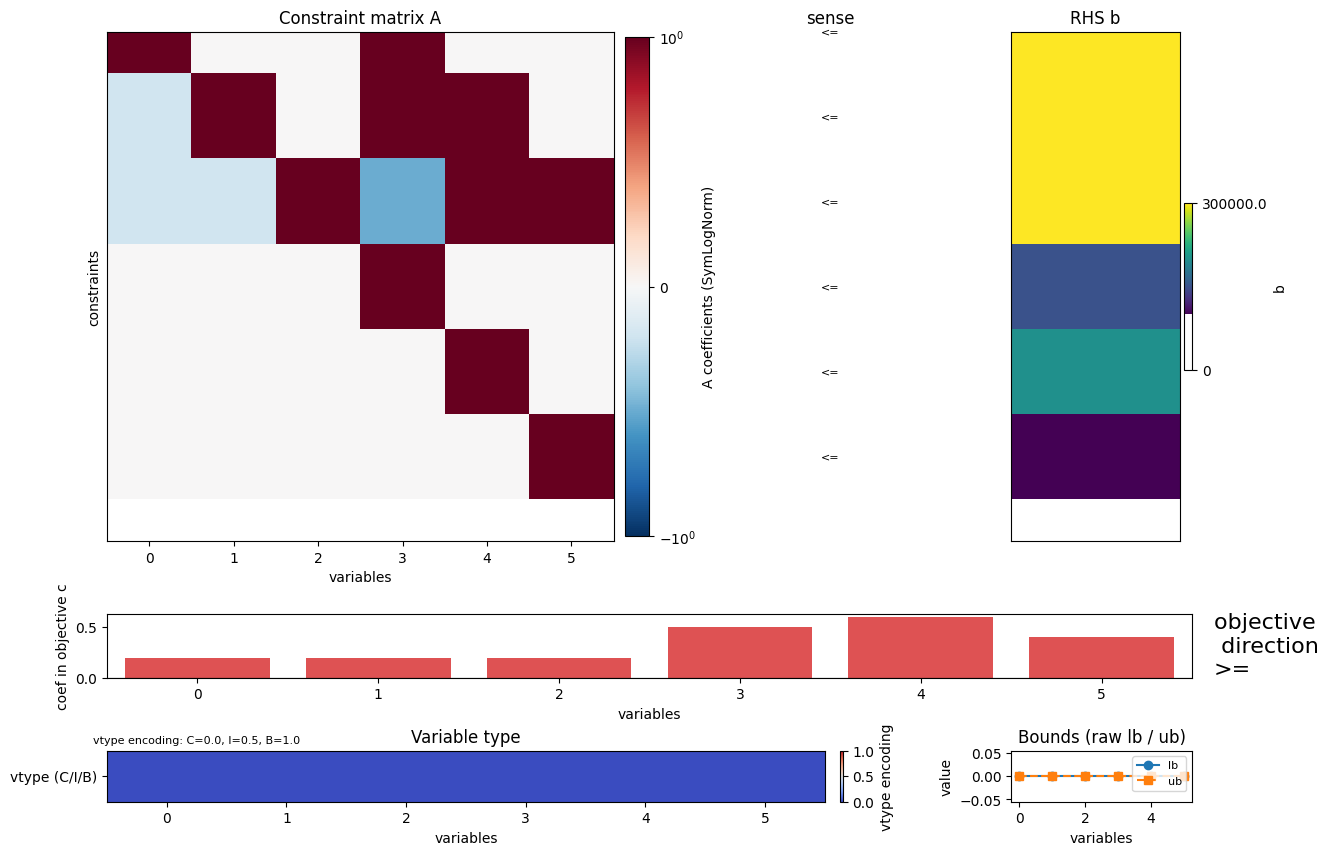


=== Single-image analysis (fine-tuned model) ===
Question    : Describe the structure of this MILP heatmap: number of variables, number of constraints, matrix density, fraction of binary variables, fraction of integer variables, and objective direction (minimize or maximize).
Ground Truth: Variables: 6, Constraints: 6, Density: high, Binary: 0%, Integer: 0%, Objective: maximize
Model Output: system
You are a helpful assistant.
user
Describe the structure of this MILP heatmap: number of variables, number of constraints, matrix density, fraction of binary variables, fraction of integer variables, and objective direction (minimize or maximize).
assistant
Variables: 2, Constraints: 3, Density: high, Binary: 0%, Integer: 100%, Objective: minimize


In [42]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# If True, load one example from mmai-data/data_test.jsonl
USE_DATASET: bool = True
TEST_INDEX: int = 150  # which test example to inspect

# Fallback URL if you want to test on an arbitrary image instead
TEST_IMAGE: str = "http://images.cocodataset.org/val2017/000000039769.jpg"

TEST_QUESTION: str = (
    "Describe the structure of this MILP heatmap: "
    "number of variables, number of constraints, matrix density, "
    "fraction of binary variables, fraction of integer variables, "
    "and objective direction (minimize or maximize)."
)
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================



import io, os, json, requests
from pathlib import Path
from PIL import Image, UnidentifiedImageError


def _get_test_jsonl_path() -> Path | None:
    """Resolve mmai-data/data_test.jsonl from cwd or DATA_JSONL (same logic as 3.2 / 6.2)."""
    for base in [Path.cwd(), Path.cwd().parent]:
        p = base / "mmai-data" / "data_test.jsonl"
        if p.exists():
            return p
    dj = globals().get("DATA_JSONL")
    if dj:
        p = Path(dj).parent / "data_test.jsonl"
        if p.exists():
            return p
    return None


def _load_from_dataset(index: int):
    test_path = _get_test_jsonl_path()
    if not test_path:
        raise FileNotFoundError("Cannot find mmai-data/data_test.jsonl; please run Problem 2 first.")
    with open(test_path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    if not lines:
        raise RuntimeError("data_test.jsonl is empty.")
    rec = json.loads(lines[index % len(lines)])
    img_rel = rec.get("image", "")
    img_path = test_path.parent / img_rel
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = Image.open(img_path).convert("RGB")
    question = rec.get("question") or TEST_QUESTION
    gt = rec.get("answer") or ""
    img_id = rec.get("image", img_rel)
    return img, question, gt, img_id


def _load_from_url(url: str):
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    try:
        return Image.open(io.BytesIO(resp.content)).convert("RGB"), TEST_QUESTION, "", url
    except UnidentifiedImageError:
        tmp_path = "temp_image.jpg"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        img = Image.open(tmp_path).convert("RGB")
        try:
            os.remove(tmp_path)
        except Exception:
            pass
        return img, TEST_QUESTION, "", url


# Load image + question + ground truth
if USE_DATASET:
    loaded_img, question, gt_text, img_id = _load_from_dataset(TEST_INDEX)
else:
    loaded_img, question, gt_text, img_id = _load_from_url(TEST_IMAGE)

print("Image:", img_id)
display(loaded_img)

# Prepare messages
messages = [{"role": "user", "content": [
    {"type": "image", "image": loaded_img},
    {"type": "text", "text": question},
]}]

# Encode and generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

with torch.no_grad():
    out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

# Decode output
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]

print("\n=== Single-image analysis (fine-tuned model) ===")
print("Question    :", question)
if gt_text:
    print("Ground Truth:", gt_text)
print("Model Output:", output_text)


# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?